# Trabajo Práctico 1: Un clima estresante
## Alumnos: Córdoba Lucía, Gagliardi Lara y Sánchez Joaquín

El registro de datos meteorológicos es importante para la comprensión y predicción de las condiciones atmosféricas, influyendo en diversos aspectos de la vida humana, como la agricultura, la investigación, la gestión de recursos naturales, la planificación ambiental y la preparación ante desastres hasta la investigación científica. 

Para el caso de Australia existe SILO (Scientific Information for Land Owners), una base de datos en línea que proporciona datos climáticos que incluyen variables como temperatura, precipitación, humedad relativa, evaporación y radiación solar.

Los datos provistos corresponden a con registros diarios proporcionados por SILO para las coordenadas (-27.9927, 152.6906) durante el período 2019-2023.

### Carga de módulos

In [1]:
import polars as pl

import pyprojroot

import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from plotnine import aes, geom_line, geom_point, ggplot, scale_x_continuous, labs, theme_bw, theme, element_text, element_blank, element_rect, facet_wrap, geom_density

import math

ROOT = pyprojroot.here()

### Carga de datos

En primer lugar, cargamos los datos meteorológicos de la ciudad rural en los años 2019 a 2023.

In [2]:
atmosfera19 = pl.read_csv(ROOT / "2019" / "atmosfera.csv")
energia19 = pl.read_csv(ROOT / "2019" / "energia.csv")
lluvias19 = pl.read_csv(ROOT / "2019" / "lluvias.csv")

atmosfera20 = pl.read_csv(ROOT / "2020" / "atmosfera.csv")
energia20 = pl.read_csv(ROOT / "2020" / "energia.csv")
lluvias20 = pl.read_csv(ROOT / "2020" / "lluvias.csv")

atmosfera21 = pl.read_csv(ROOT / "2021" / "atmosfera.csv")
energia21 = pl.read_csv(ROOT / "2021" / "energia.csv")
lluvias21 = pl.read_csv(ROOT / "2021" / "lluvias.csv")

atmosfera22 = pl.read_csv(ROOT / "2022" / "atmosfera.csv")
energia22 = pl.read_csv(ROOT / "2022" / "energia.csv")
lluvias22 = pl.read_csv(ROOT / "2022" / "lluvias.csv")

atmosfera23 = pl.read_csv(ROOT / "2023" / "atmosfera.csv")
energia23 = pl.read_csv(ROOT / "2023" / "energia.csv")
lluvias23 = pl.read_csv(ROOT / "2023" / "lluvias.csv")

Luego, unimos los datos en una única base de datos.

In [3]:
datos2019 = atmosfera19.join(energia19, on = "fecha", how = "inner").join(lluvias19, on = "fecha", how = "inner")
datos2020 = atmosfera20.join(energia20, on = "fecha", how = "inner").join(lluvias20, on = "fecha", how = "inner")
datos2021 = atmosfera21.join(energia21, on = "fecha", how = "inner").join(lluvias21, on = "fecha", how = "inner")
datos2022 = atmosfera22.join(energia22, on = "fecha", how = "inner").join(lluvias22, on = "fecha", how = "inner")
datos2023 = atmosfera23.join(energia23, on = "fecha", how = "inner").join(lluvias23, on = "fecha", how = "inner")

datos = pl.concat([datos2019, datos2020, datos2021, datos2022, datos2023], how = "vertical")

In [4]:
observaciones_total = datos.shape
observaciones_total

(1826, 8)

En el conjunto de datos hay 1826 observaciones. En los años 2019, 2021, 2022 y 2023 se registraron 365 observaciones mientras que en el año 2020 hay 366 observaciones debido a que este fue un año bisiesto.

In [5]:
datos.null_count()

fecha,t_min,t_max,hr_t_min,hr_t_max,evaporación,radiación,lluvia
u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0


En ninguna de las variables se presentaron valores faltantes.

A continuación analizamos la cantidad total de lluvia caída en la zona y cuánto se corresponde a cada año.

In [6]:
lluvia_total = datos["lluvia"].sum()
lluvia_total

4327.799999999999

In [7]:
# Agregamos una columna con el año
datos = datos.with_columns(
    pl.col("fecha")
    .str.to_date()
    .dt.year()
    .alias("anio")
)

lluvia_por_anio = (
    datos
    .group_by("anio")
    .agg(
    pl.col("lluvia").sum().alias("lluvia_total")
    )
    .sort("anio")
)

lluvia_por_anio

anio,lluvia_total
i32,f64
2019,346.6
2020,811.6
2021,950.4
2022,1476.2
2023,743.0


La cantidad total de lluvia caída en la zona rural es de 4327.79 milímetros (mm). El año 2019 fue el año con menores precipitaciones (346.6 mm) mientras que el año 2022 presentó la mayor cantidad de milímentros llovidos (1476.2 mm). 

Realizamos un gráfico de barras para visualizar la información anterior.

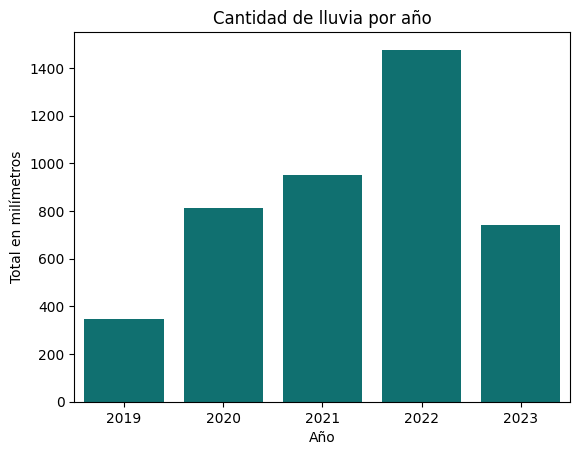

In [8]:
# Creamos una base con la lluvia total para cada año
datos_agrupado_anio = (
    datos
    .group_by("anio")
    .agg(
        pl.col("lluvia")
        .sum()
        .alias("total")
        )
)

sns.barplot(
    x = "anio", 
    y = "total", 
    color = "teal",
    data = datos_agrupado_anio 
    )
plt.title(
    "Cantidad de lluvia por año"
)

plt.xlabel("Año")
plt.ylabel("Total en milímetros");

Se observa que la cantidad total de lluvia por año presenta un aumento desde el año 2019, alcanzando su punto máximo en el año 2022 con alrededor de 1500 mm. En el año 2023, la cantidad de lluvia disminuyó, con un total menor al del año 2020.

Después, graficamos la cantidad de lluvia por mes y año a través de un gráfico de líneas.

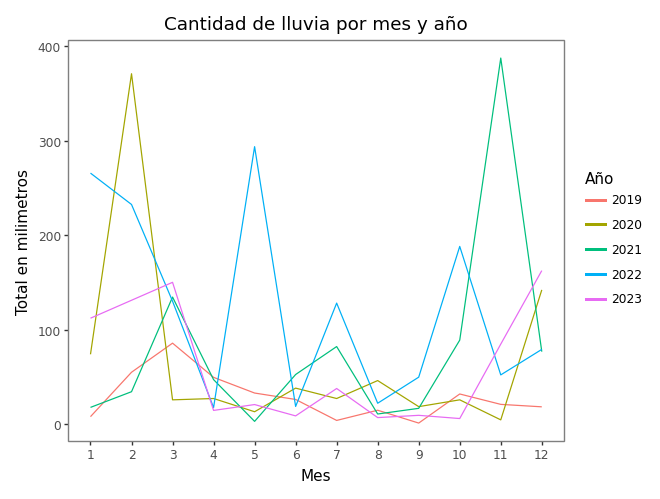

In [9]:
# Agregamos una columna con el mes
datos = datos.with_columns(
    pl.col("fecha")
    .str.to_date()
    .dt.month()
    .alias("mes")
)

# Creamos una base con el total de lluvia por mes y año
datos_agrupado_anio_mes = (
    datos
    .group_by("anio", "mes")
    .agg(
        pl.col("lluvia")
        .sum()
        .alias("total")
        )
    .sort(["anio", "mes"])
)

grafico = (
    ggplot(datos_agrupado_anio_mes) +  
    aes(x = "mes", y = "total", color = "factor(anio)") + 
    geom_line() +
    scale_x_continuous(breaks = range(1, 13)) +
    theme_bw() + 
    labs(
        title = "Cantidad de lluvia por mes y año",
        x = "Mes",
        y = "Total en milimetros",
        color = "Año"
    ) +
    theme(
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
    )
)

grafico

En el gráfico anterior se observa el total lluvia (mm) por mes no presenta el mismo comportamiento a través de los años. Si bien existe una tendencia general a registrar mayores precipitaciones en los primeros (enero-marzo) y últimos meses del año (octubre-diciembre) con una baja en los meses intermedios, se observan algunas regularidades en el año 2022, registrando picos en mayo y julio.

La cantidad total de lluvia de los años 2019 y 2023 presenta un comportamiento similar, con un pequeño pico en el mes de marzo, y cantidades similares para los meses siguientes, a excepción del mes de diciembre de 2023 donde las precipitaciones fueron mayores. En el año 2020, la mayor cantidad de lluvia ocurrió en el mes de febrero, seguido del mes de diciembre. Tanto en 2021 como en 2022 hay varios meses con gran cantidad de precipitaciones.

Para analizar cómo varía las temperaturas máximas y mínimas a lo largo del tiempo graficamos el promedio de las temperaturas para cada mes en todos los años.

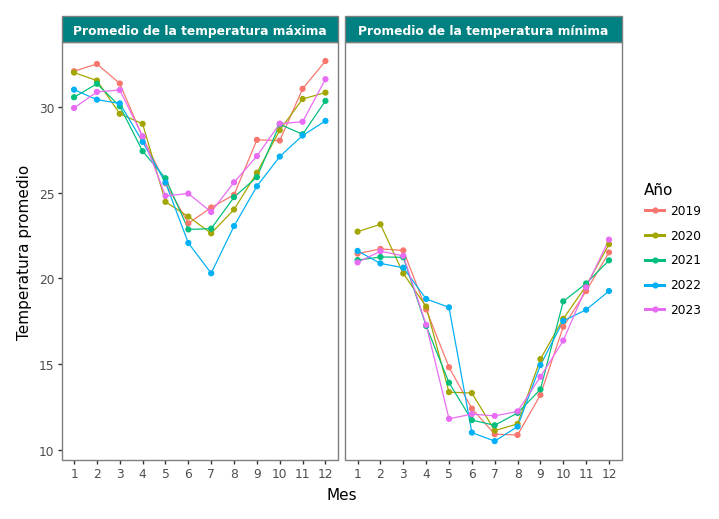

In [10]:
# Creamos una base con la temperatura mínima y máxima promedio para cada mes y año
datos_temp_mes = (
    datos
    .group_by("mes", "anio")
    .agg(
        pl.col("t_min")
        .mean()
        .alias("Promedio de la temperatura mínima"), 
        pl.col("t_max")
        .mean()
        .alias("Promedio de la temperatura máxima"),
        pl.col("fecha").min()
        )
        .sort("anio", "mes")
)
datos_temp_mes

# Para poder graficar ambas temperaturas promedios usando facet_wrap() es necesario que 
# haya una columna que indique si la temperatura es máxima o mínima por lo que es necesario
# que las temperaturas promedios se encuentren en una misma columna, es decir, hay que 
# pasarlo a formato largo

datos_temp_mes_largo = (
    datos_temp_mes
    .unpivot(
        index = ["mes", "anio"],
        on = ["Promedio de la temperatura mínima", "Promedio de la temperatura máxima"],
        variable_name = "tipo",
        value_name = "promedio_t"
    )
)

(
ggplot(datos_temp_mes_largo) +
aes(
    x = "mes",
    y = "promedio_t",
    color = "factor(anio)"
    ) +
geom_line() +
geom_point() +
facet_wrap("~tipo") +
scale_x_continuous(breaks = range(1, 13)) +
theme_bw() +
labs(
    x = "Mes",
    y = "Temperatura promedio",
    color = "Año"
    ) +
theme(    
    figure_size=(7, 5),
    panel_grid_minor = element_blank(),
    panel_grid_major = element_blank(),
    strip_background = element_rect(fill = "teal", color = None),
    strip_text = element_text(color = "white", weight = "bold")
    )
)

Se observa un comportamiento similar entre las temperaturas mínimas y máximas promedio de los años analizados. En los meses de invierno las temperaturas promedio son más bajas.

Analizamos la asociación entre la t5emperatura mínima y máxima a través de un gráfico de dispersión.

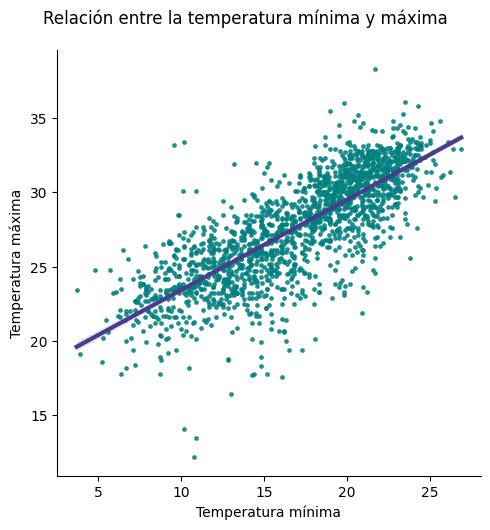

In [11]:
g = sns.lmplot(
    data = datos, 
    x = "t_min", 
    y = "t_max",
    scatter_kws = {"s": 6, "color": "teal"},
    line_kws = {"color": "darkslateblue", "linewidth": 3}
)

g.set_xlabels("Temperatura mínima")
g.set_ylabels("Temperatura máxima")
g.set_titles("Relación entre la temperatura mínima y máxima")
g.fig.suptitle(
    "Relación entre la temperatura mínima y máxima",
    y=1.05
);

La temperatura mínima y máxima están relacionadas positivamente, de forma aproximadamente lineal.

Calculamos la amplitud térmica y analizamos su comportamiento a nivel global y a lo largo del tiempo.

In [12]:
datos = datos.with_columns(
    amplitud_termica = pl.col("t_max") - pl.col("t_min")
)

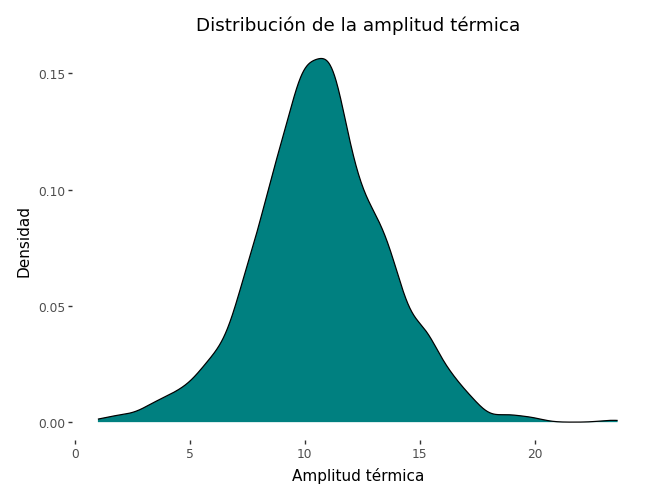

In [13]:
# Globalmente
(
ggplot(datos) + 
geom_density(
    aes("amplitud_termica"),
    fill = "teal"
    ) + 
labs(
    x = "Amplitud térmica",
    y = "Densidad",
    title = "Distribución de la amplitud térmica"
    ) + 
theme(    
    panel_grid_minor = element_blank(),
    panel_grid_major = element_blank(),
    panel_background = element_blank()
    )
)


Se observa que, en general, la amplitud térmica varía entre los 5 y 18 grados. Se aprecia una leve asimetría a la derecha.

A continuación, analizamos el comportamiento de la amplitud térmica a través de los años.

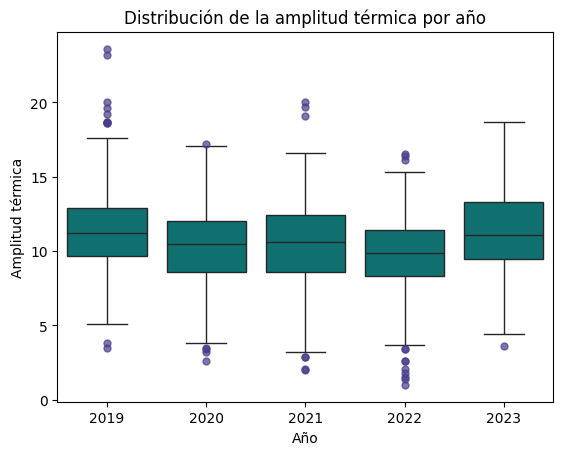

In [14]:
# a lo largo del tiempo
g = sns.boxplot(
    x = "anio", 
    y = "amplitud_termica", 
    color = "teal",
    data = datos,
    flierprops={
    "marker": "o",
    "markerfacecolor": "darkslateblue",
    "markeredgecolor": "darkslateblue",
    "markersize": 5,
    "alpha": 0.7
    })
g.set_xlabel("Año")
g.set_ylabel("Amplitud térmica")
g.set_title("Distribución de la amplitud térmica por año");

Para los años en estudio, la amplitud térmica registrada presenta valores similares en cuanto a mediana y variancia. En el año 2023 se observan valores algo mayores que en los años anteriores.

Analizamos la asociación entre la amplitud térmica y la temperatura mínima o máxima del día.

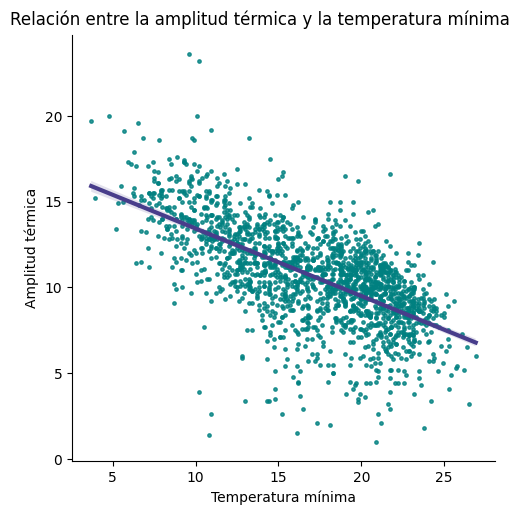

In [15]:
g = sns.lmplot(
    data = datos,
    x = "t_min",
    y = "amplitud_termica",
    scatter_kws = {"s": 6, "color": "teal"},
    line_kws = {"color": "darkslateblue", "linewidth": 3}
)

g.set_xlabels("Temperatura mínima")
g.set_ylabels("Amplitud térmica")

g.fig.suptitle(
    "Relación entre la amplitud térmica y la temperatura mínima",
    y = 1.02
);


In [ ]:
datos.select(
    pl.corr("t_min", "amplitud_termica")
)

t_min
f64
-0.635425


Se observa que la amplitud térmica se relaciona con la temperatura mínima de forma aproximadamente lineal, de manera que a medida que la temperatura mínima aumenta, la amplitud térmica disminuye.

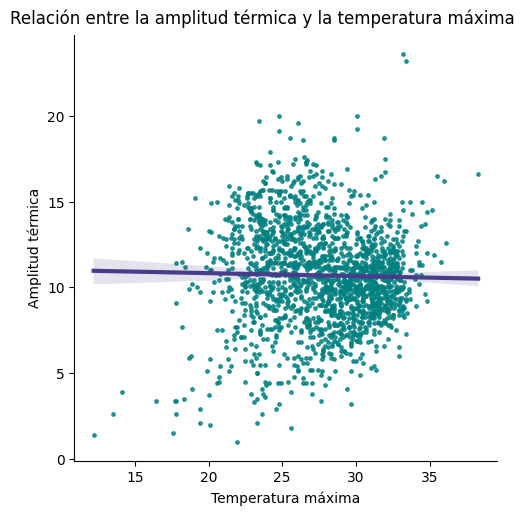

In [16]:
g = sns.lmplot(
    data = datos, 
    x = "t_max", 
    y = "amplitud_termica",
    scatter_kws = {"s": 6, "color": "teal"},
    line_kws = {"color": "darkslateblue", "linewidth": 3}
)

g.set_xlabels("Temperatura máxima")
g.set_ylabels("Amplitud térmica")

g.fig.suptitle(
    "Relación entre la amplitud térmica y la temperatura máxima",
    y = 1.02
);

In [17]:
datos.select(
    pl.corr("amplitud_termica", "t_max")
)

amplitud_termica
f64
-0.021824


No se observa una relación entre la amplitud térmica con la temperatura máxima observada.

Analizamos la relación entre la amplitud térmica y el total de lluvia (mm).

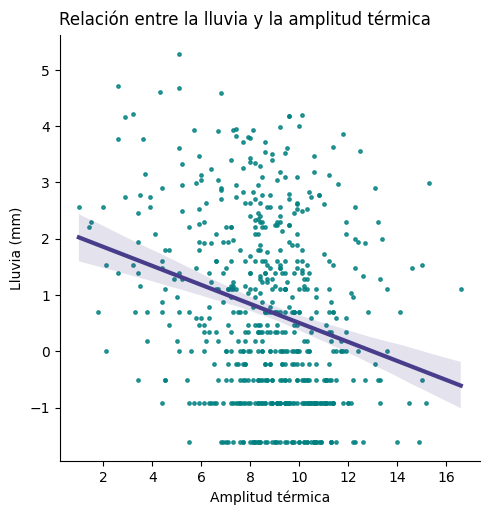

In [18]:
# Nos quedamos con los días en los que se registraron lluvias
datos_con_lluvia = datos.filter(pl.col("lluvia") != 0)

# Utilizamos la escala logarítmica para una mejor visualización de los datos ya que existe 
# un día con 200 mm de lluvia, valor muy grande en relación al resto
datos_con_lluvia = datos_con_lluvia.with_columns(
    pl.col("lluvia").log().alias("log_lluvia")
)

g = sns.lmplot(
    data = datos_con_lluvia, 
    x = "amplitud_termica",
    y = "log_lluvia", 
    scatter_kws = {"s": 6, "color": "teal"},
    line_kws = {"color": "darkslateblue", "linewidth": 3}
)

g.set_xlabels("Amplitud térmica")
g.set_ylabels("Lluvia (mm)");

g.fig.suptitle(
    "Relación entre la lluvia y la amplitud térmica",
    y = 1.02
);

In [19]:
datos.select(
    pl.corr("lluvia", "amplitud_termica")
)

lluvia
f64
-0.267443


No se ve una relación clara entre la cantidad de lluvia y la amplitud térmica.

Para analizar la radiación, calculamos la radiación media para cada mes y obtenemos cúales son los que presentan valores ayores.

In [20]:
(
    datos
    .group_by("mes")
    .agg(pl.col("radiación")
    .mean()
    .alias("prom_rad"))
    .sort("prom_rad", descending=True)
)

mes,prom_rad
i8,f64
12,25.363226
1,24.005806
11,23.785333
2,22.77305
10,22.729032
…,…
4,17.395333
8,17.171613
5,14.414839


Los meses de verano presentan radiación promedio mayor que el resto, con valores alrededor de los 23 (MJ / m²).

Buscamos en qué mes a lo largo de los 5 años de datos se observó el mayor nivel de evaporación.

In [21]:
(
    datos
    .group_by("mes")
    .agg(pl.col("evaporación")
    .sum())
    .sort("evaporación")
    .tail(1)
)

mes,evaporación
i8,f64
12,1056.7


In [22]:
(
    datos
    .group_by("anio", "mes")
    .agg(pl.col("evaporación")
    .sum())
    .sort("evaporación")
    .tail(1)
)

anio,mes,evaporación
i32,i8,f64
2019,12,274.2


Al considerar los 5 años en conjunto se obtuvo que el mes de diciembre presenta mayor evaporación total, con 1056.7 (mm). Si analizamos nivel de evaporación total por mes para cada año por separado, en diciembre de 2019 se registró el mayor valor (274.2 mm).

### Días de estrés

Los “días de estrés” se refieren a días en que las condiciones ambientales son desfavorables para el crecimiento óptimo de los cultivos. Un factor que determina el nivel de estrés es la temperatura ya que cuando estas son extremas, pueden causar estrés térmico en los cultivos. 

A continuación, clasificamos los días de estrés considerando la temperatura máxima. Se establece una temperatura de referencia de 32 grados centígrados.

In [ ]:
# Creamos una columna indicando si se considera un día de estrés o no
datos_estres = datos.with_columns(
    pl.when(pl.col('t_max') >= 32)
    .then(pl.lit(1))
    .otherwise(pl.lit(0))
    .alias('estres')
)
datos_estres

fecha,t_min,t_max,hr_t_min,hr_t_max,evaporación,radiación,lluvia,anio,mes,amplitud_termica,estres
str,f64,f64,f64,f64,f64,f64,f64,i32,i8,f64,i32
"""2019-01-01""",20.3,31.1,87.8,46.3,8.5,29.6,0.0,2019,1,10.8,0
"""2019-01-02""",20.1,31.2,99.1,51.3,7.7,27.1,0.0,2019,1,11.1,0
"""2019-01-03""",20.3,31.8,100.0,55.5,6.7,26.5,1.0,2019,1,11.5,0
"""2019-01-04""",21.0,31.2,74.4,40.7,9.4,29.3,0.0,2019,1,10.2,0
"""2019-01-05""",22.4,31.4,83.8,49.4,8.0,23.7,0.0,2019,1,9.0,0
…,…,…,…,…,…,…,…,…,…,…,…
"""2023-12-27""",20.6,30.4,100.0,64.3,6.3,22.2,11.6,2023,12,9.8,0
"""2023-12-28""",23.6,32.2,100.0,62.0,7.3,22.4,0.0,2023,12,8.6,1
"""2023-12-29""",25.0,33.3,100.0,62.2,7.6,27.1,1.4,2023,12,8.3,1


Obtenemos el total de días de estrés ocurridos entre el 14-10-2019 y el 03-12-2019.

In [24]:
(
    datos_estres
    .filter(pl.col("fecha") >= "2019-10-14", pl.col("fecha") <= "2019-12-03")["estres"]
    .value_counts()
)

estres,count
i32,u32
1,11
0,40


En el período analizado hubo 11 días cuya temperatura máxima excedió los 32ºC.

Calculamos la cantidad de días de estrés térmico por mes a lo largo de los 5 años y lo visualizamos en un gráfico de línea.

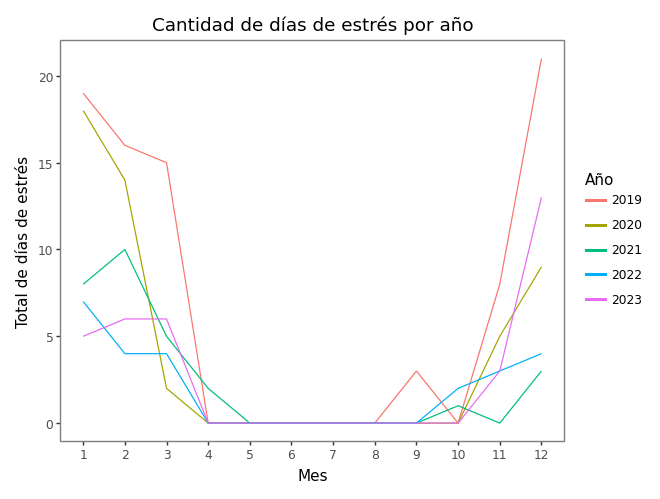

In [25]:
# Creamos una base con los días de estrés para cada mes y año
datos_estres_agrupado_mes_anio = (
datos_estres
.group_by("mes", "anio")
.agg(
    pl.col("estres")
    .sum()
    .alias("total")
    )
.sort("total", descending = True)
)

grafico = (
    ggplot(datos_estres_agrupado_mes_anio) +  
    aes(x = "mes", y = "total", color = "factor(anio)") + 
    geom_line() +
    scale_x_continuous(breaks = range(1, 13)) +
    theme_bw() + 
    labs(
        title = "Cantidad de días de estrés por año",
        x = "Mes",
        y = "Total de días de estrés",
        color = "Año"
    ) +
    theme(
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
    )
)

grafico

Los días de estrés ocurren con mayor frecuencia en los meses de verano, es decir, entre noviembre y marzo. En los 5 años analizados no ocurrieron días de estrés en los meses de mayo a agosto.

Elaboramos una función que, dado el conjunto de datos, una fecha de inicio y una fecha de fin, devuelve la cantidad de días de estrés térmico dentro del rango de fechas indicado.

In [ ]:
def calcular_dias_estres(datos, inicio, fin):
    """ 
    Cálculo de la cantidad de días de éstres ocurridos en un período:
        datos: dataframe con una columna "fecha" y con "estres" con valores booleanos
        inicio: fecha de inicio del período (String 'YYYY-MM-DD')
        fin: fecha del fin del período (String 'YYYY-MM-DD')
    """
    formato = "%Y-%m-%d"
    try:
        datetime.datetime.strptime(inicio, formato)
        datetime.datetime.strptime(fin, formato)
    except ValueError:
        raise ValueError ("Las fechas deben ingresarse en el formato 'YYYY-MM-DD'.")
    if inicio < "2019-01-01" or fin > "2023-12-31":
        raise ValueError ("Fechas fuera de rango. La base de datos contiene registros desde 2019-01-01 hasta 2023-12-31.")
    suma_estres = datos.filter(
        pl.col("fecha").is_between(pl.lit(inicio), pl.lit(fin))
    ).select(
        pl.col("estres").sum()
    ).item()
    return f"Entre la fecha {inicio} y la fecha {fin} hubo {suma_estres} días de estrés."

## Déficit de presión de vapor

Calculamos el déficit de presión de vapor en el momento que se registró la temperatura máxima.

In [39]:
# Agregamos columnas con presión de vapor de saturación (vps), presión de vapor actual (vpa)
# y déficit de presión de vapor (vpd) para cada día.

datos = (
    datos.with_columns(
        vps = 0.61078 * (17.27 * pl.col("t_max") / (pl.col("t_max") + 237.3)).exp()
    )
    .with_columns(
    vpa = pl.col("vps") * pl.col("hr_t_max") / 100 
    )
    .with_columns(
    vpd = pl.col("vps") - pl.col("vpa") 
    )
)
datos

fecha,t_min,t_max,hr_t_min,hr_t_max,evaporación,radiación,lluvia,anio,mes,amplitud_termica,vps,vpa,vpd
str,f64,f64,f64,f64,f64,f64,f64,i32,i8,f64,f64,f64,f64
"""2019-01-01""",20.3,31.1,87.8,46.3,8.5,29.6,0.0,2019,1,10.8,4.518084,2.091873,2.426211
"""2019-01-02""",20.1,31.2,99.1,51.3,7.7,27.1,0.0,2019,1,11.1,4.543851,2.330995,2.212855
"""2019-01-03""",20.3,31.8,100.0,55.5,6.7,26.5,1.0,2019,1,11.5,4.701147,2.609137,2.09201
"""2019-01-04""",21.0,31.2,74.4,40.7,9.4,29.3,0.0,2019,1,10.2,4.543851,1.849347,2.694504
"""2019-01-05""",22.4,31.4,83.8,49.4,8.0,23.7,0.0,2019,1,9.0,4.595767,2.270309,2.325458
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2023-12-27""",20.6,30.4,100.0,64.3,6.3,22.2,11.6,2023,12,9.8,4.341248,2.791423,1.549826
"""2023-12-28""",23.6,32.2,100.0,62.0,7.3,22.4,0.0,2023,12,8.6,4.80862,2.981344,1.827276
"""2023-12-29""",25.0,33.3,100.0,62.2,7.6,27.1,1.4,2023,12,8.3,5.115246,3.181683,1.933563


Creamos una variable que clasifique a los días de acuerdo a la siguiente regla:
- VPD entre 0 y 0.5 kPa: Condiciones muy húmedas.
- VPD entre 0.5 y 1.0 kPa: Condiciones moderadamente húmedas.
- VPD entre 1.0 y 2.0 kPa: Condiciones semiáridas.
- VPD entre 2.0 y 3.0 kPa: Condiciones áridas.
- VPD mayor a 3.0 kPa: Condiciones extremadamente secas.

In [40]:
datos = datos.with_columns(
    pl.when((pl.col("vpd") >= 0) & (pl.col("vpd") < 0.5))
    .then(pl.lit("Condiciones muy húmedas"))
    
    .when((pl.col("vpd") >= 0.5) & (pl.col("vpd") < 1))
    .then(pl.lit("Condiciones moderadamente húmedas"))
    
    .when((pl.col("vpd") >= 1) & (pl.col("vpd") < 2))
    .then(pl.lit("Condiciones semiáridas"))
    
    .when((pl.col("vpd") >= 2) & (pl.col("vpd") < 3))
    .then(pl.lit("Condiciones áridas"))
    
    .otherwise(pl.lit("Condiciones extremadamente secas"))
    .alias("condicion_humedad")
)
datos

fecha,t_min,t_max,hr_t_min,hr_t_max,evaporación,radiación,lluvia,anio,mes,amplitud_termica,vps,vpa,vpd,condicion_humedad
str,f64,f64,f64,f64,f64,f64,f64,i32,i8,f64,f64,f64,f64,str
"""2019-01-01""",20.3,31.1,87.8,46.3,8.5,29.6,0.0,2019,1,10.8,4.518084,2.091873,2.426211,"""Condiciones áridas"""
"""2019-01-02""",20.1,31.2,99.1,51.3,7.7,27.1,0.0,2019,1,11.1,4.543851,2.330995,2.212855,"""Condiciones áridas"""
"""2019-01-03""",20.3,31.8,100.0,55.5,6.7,26.5,1.0,2019,1,11.5,4.701147,2.609137,2.09201,"""Condiciones áridas"""
"""2019-01-04""",21.0,31.2,74.4,40.7,9.4,29.3,0.0,2019,1,10.2,4.543851,1.849347,2.694504,"""Condiciones áridas"""
"""2019-01-05""",22.4,31.4,83.8,49.4,8.0,23.7,0.0,2019,1,9.0,4.595767,2.270309,2.325458,"""Condiciones áridas"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""2023-12-27""",20.6,30.4,100.0,64.3,6.3,22.2,11.6,2023,12,9.8,4.341248,2.791423,1.549826,"""Condiciones semiáridas"""
"""2023-12-28""",23.6,32.2,100.0,62.0,7.3,22.4,0.0,2023,12,8.6,4.80862,2.981344,1.827276,"""Condiciones semiáridas"""
"""2023-12-29""",25.0,33.3,100.0,62.2,7.6,27.1,1.4,2023,12,8.3,5.115246,3.181683,1.933563,"""Condiciones semiáridas"""


Calculamos la proporción de días en cada condición y los representamos en un gráfico.

In [ ]:
datos_humedad = (
    datos["condicion_humedad"]
    .value_counts(normalize = True, name = "Proporción"))
datos_humedad

InvalidOperationError: mul operation not supported for dtypes `str` and `str`

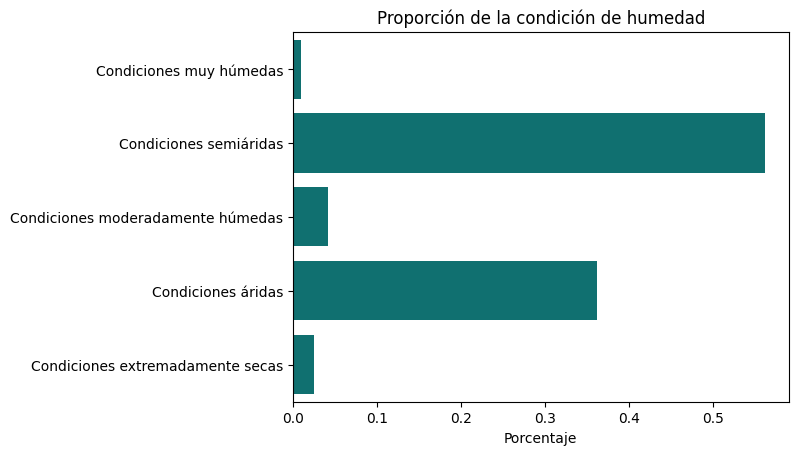

In [42]:
sns.barplot(
    y = "condicion_humedad",
    x = "proportion",
    color = "teal",
    data = datos_humedad 
    )

plt.title(
    "Proporción de la condición de humedad"
)

plt.xlabel("Porcentaje")
plt.ylabel("");